
╔══════════════════════════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING — POLYMARKET TIMESERIES BUILDER                  ║
║  Run cells top-to-bottom. Only the CONFIG cell requires manual input.        ║
╚══════════════════════════════════════════════════════════════════════════════╝




#### 0. Config

In [1]:
# %% ── CELL 0 : CONFIG ───────────────────────────────────────────────────────
from pathlib import Path

# Folders
DATA_DIR     = Path("./Data")
MODELS_DIR   = Path("./Models")
RESULTS_DIR  = Path("./Results")
for p in (MODELS_DIR, RESULTS_DIR):
    p.mkdir(exist_ok=True, parents=True)

# File patterns
GOLD_PANEL_GLOB = "gold_panel_*.csv"          # dynamic date in file name
BLOOMBERG_XLSX_CANDIDATES = [
    DATA_DIR / "Indicators Data bloomberg.xlsx",
    DATA_DIR / "Indicators-Data-bloomberg.xlsx",
    DATA_DIR / "Indicators_Data_bloomberg.xlsx",
]
TARGET_SHEET    = "GOLD USD SPOT PER OZ"
TARGET_COL      = "Close"

def resolve_bloomberg_xlsx(candidates: list[Path], data_dir: Path) -> Path:
    for p in candidates:
        if p.exists():
            return p
    # Fallback: pick any workbook that looks like the indicators file
    wildcard = sorted(data_dir.glob("*Indicators*Data*bloomberg*.xlsx"))
    if wildcard:
        return wildcard[0]
    tried = "\n  - ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "Bloomberg workbook not found. Tried:\n"
        f"  - {tried}\n"
        "Expected something like 'Indicators Data bloomberg.xlsx' in ./Data."
    )

BLOOMBERG_XLSX = resolve_bloomberg_xlsx(BLOOMBERG_XLSX_CANDIDATES, DATA_DIR)
print(f"Using Bloomberg workbook: {BLOOMBERG_XLSX}")

# ─── Modelling ───────────────────────────────────────────────────────────────
BAR_MINUTES         = 5          # native cadence of the Bloomberg close series
RETURN_HORIZON_MIN  = 15         # ⟵ target-return horizon in MINUTES.
                                 #    60   -> 1-hour returns (current default)
                                 #    240  -> 4-hour returns (to test next)
                                 #    1440 -> next-day returns (to test later)
                                 #    5    -> old 5-min behaviour
HORIZON_STEPS       = max(1, RETURN_HORIZON_MIN // BAR_MINUTES)  # #bars ahead predicted
AR_LAGS             = [1, 2, 3, 6, 12]       # past-return lags (in 5-min bars)
AR_MA_WINDOWS       = [3, 6, 12, 36]         # rolling-mean windows on past returns
WINDOW_SCHEMES  = {                          # {label: ("fixed"|"expanding", size)}
    "fixed120":  ("fixed", 120),
    "fixed240":  ("fixed", 240),
    "fixed300":  ("fixed", 300),
    "expanding": ("expanding", 120),         # 120 = minimum training size before first prediction
}
LSTM_TEST_BLOCK = 12           # LSTM retrain cadence — predict next 12 obs per refit
LSTM_SEQ_LEN    = 12           # look-back length fed into the LSTM (≈ 1 hour)
LSTM_EPOCHS     = 8
LSTM_BATCH      = 32
RF_N_ESTIMATORS = 200
RANDOM_STATE    = 67

# ─── Regularisation knobs (tunable from here for quick iteration) ────────────
# Ridge penalty. Start around 10–100 when Polymarket features are still raw-ish;
# drop to ~1.0 once proper feature engineering / selection has been done.
RIDGE_ALPHA     = 10.0

# PCA pre-compression applied to the Polymarket block ONLY (AR features are
# kept raw, they are already in return-space and low-dim).
# Set PCA_N_COMPONENTS = 0 (or None) to disable PCA entirely.
#   typical range: 20–40 while Polymarket dim is high;
#   after feature engineering you can probably drop it to 0.
PCA_N_COMPONENTS = 30

# ─── Traditional indicators — separate PCA and feature engineering controls ──
# Independent PCA for the Bloomberg traditional block: typically 3–8 components
# (one per macro factor: rates, equities, FX, commodities, vol, etc.).
# Set to 0 to disable PCA on the traditional block entirely.
PCA_N_COMPONENTS_TRADITIONAL = 5

# Forward-fill cap when resampling daily Bloomberg indicators to the 5-min gold
# clock.  None = carry indefinitely (standard for Bloomberg daily data);
# set an integer to cap stale carries (e.g., 288 = ~1 trading day on a 5-min grid).
TRADITIONAL_MAX_FFILL_BARS   = None

# Add a staleness counter feature for each traditional indicator:
# tells the model how many 5-min bars have elapsed since the last real tick.
# Useful because daily series are stale for ~288 bars between updates.
TRADITIONAL_USE_STALENESS    = True

# Drop raw price-level columns after stationarising (default True).
# They are collinear with the diff/log-return columns and can confuse Ridge.
TRADITIONAL_DROP_PRICE_LEVELS = True

# AR features of the gold log-return appended to the traditional predictor matrix.
# Must mirror the full AR feature set used for the polymarket block so that both
# sets of models see the same autoregressive information:
#   - 5 lagged returns  (AR_LAGS)
#   - 4 rolling means   (AR_MA_WINDOWS)
#   - 2 rolling stds    ([12, 36])
# These are passed separately to build_X_traditional via ar_lags / ar_ma_windows /
# ar_vol_windows; keeping them as explicit config allows independent tuning later.
TRADITIONAL_AR_LAGS       = [1, 2, 3, 6, 12]   # must match AR_LAGS
# ar_ma_windows and ar_vol_windows for the trad block are passed as AR_MA_WINDOWS
# and [12, 36] directly in Cell 5 (they share the same config as the poly block).

# ─── Feature engineering checkmark (variance prefilter gate) ─────────────────
# NOTE: the variance pre-filter in Cell 4.1 is a stop-gap that keeps LSTM/Ridge
# tractable while Polymarket features are still raw and high-dimensional. Once
# proper feature engineering AND selection have been done upstream (on the
# polymarket panel), the prefilter is no longer needed and can be skipped:
#   - FEATURE_ENGINEERING_DONE = False  -> prefilter ON  (keep top-N by variance)
#   - FEATURE_ENGINEERING_DONE = True   -> prefilter OFF (use all columns)
FEATURE_ENGINEERING_DONE = False

MAX_FEATURES_PREFILTER = 150   # crude variance prefilter (only used if FE not done)

# ─── Daily gap handling (Bloomberg ~23:00 break, see Cell 10) ────────────────
# Adds an `is_post_break` dummy AND a `poly_movement_during_break` feature
# (approach 2 + 3 combined — see the PDF diagnosis). Turn off to revert.
HANDLE_DAILY_GAP = True
GAP_THRESHOLD    = "60min"       # a bar-to-bar step > this counts as a session break

# Evaluation toggles
FORCE_RETRAIN   = False        # set True to ignore cached models
DRY_RUN_ROWS    = None         # e.g. 1000 to debug on a slice; None = full


Using Bloomberg workbook: Data\Indicators Data bloomberg.xlsx


#### Polymarket — Timeseries Dataset Builder
This notebook:
1. Downloads the **latest SQLite backup** from S3 (skips if already local)
2. Checks if a matching **timeseries CSV** already exists in `./Data/`
3. If not, **pivots the raw markets table** into a wide timeseries (rows = scraped_at, columns = MultiIndex[variable, question])
4. Runs a **sanity check** on the resulting dataframe


In [2]:
# %% ── CELL 1 : CONFIG ────────────────────────────────────────────────────────
import os

BUCKET_NAME     = "thesis-data-ab3rnhard"
S3_PREFIX       = "backups/"
LOCAL_DATA_DIR  = "./Data"
TABLE_NAME      = "markets"
SCRAPED_AT_COL  = "scraped_at"
QUESTION_COL    = "question"

BUCKET_FETCHING = False  # False to skip S3 fetching and use local files only

# Columns to DROP before pivoting (identifiers / near-100%-null / pure metadata)
# Add or remove entries here to control which variables end up in the timeseries.
COLS_TO_DROP = [
    "id",                    # row identifier, not a timeseries variable
    "conditionId",           # static identifier
    "slug",                  # static identifier
    "questionID",            # static identifier
    "clobTokenIds",          # static identifier
    "icon", "image",         # URL strings
    "description",           # long text
    "resolutionSource",      # text URL
    # "outcomes",              # JSON text
    # "outcomePrices",         # JSON text (parsed separately if needed)
    "events",                # JSON text
    "umaResolutionStatuses", # JSON text
    "submitted_by",          # text
    "marketMakerAddress",    # 100 % null
    "seriesColor",           # 100 % null
    "liquidityAmm",          # 100 % null
    "oneYearPriceChange",    # 100 % null
    "volume1moAmm",          # 100 % null
    "volume1wkAmm",          # 100 % null
    "volume1yrAmm",          # 100 % null
    "volume24hrAmm",         # 100 % null
    "volumeAmm",             # 100 % null
    "umaResolutionStatus",   # 99 % null
]

# AWS credentials — read from environment variables (same pattern as Health Check)
AWS_ACCESS_KEY_ID     = (os.getenv("AWS_ACCESS_KEY_ID")     or "").strip()
AWS_SECRET_ACCESS_KEY = (os.getenv("AWS_SECRET_ACCESS_KEY") or "").strip()
AWS_REGION            = (os.getenv("AWS_REGION")            or "eu-north-1").strip() or "eu-north-1"

print("✅ Config loaded.")


✅ Config loaded.


In [3]:
# %% ── CELL 2 : DEPENDENCIES ─────────────────────────────────────────────────
try:
    import boto3
except ModuleNotFoundError:
    %pip install boto3 -q
    import boto3

import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from botocore.exceptions import ClientError

print("✅ Dependencies ready.")



✅ Dependencies ready.


In [4]:
# %% ── CELL 3 : FETCH LATEST DB FROM S3 OR USE LATEST LOCAL ─────────────────
if not BUCKET_FETCHING:
    # ── find the latest local SQLite backup ──────────────────────────────────
    local_dbs = sorted(Path(LOCAL_DATA_DIR).glob("local_database_*.sqlite"))
    if not local_dbs:
        raise FileNotFoundError(
            f"No local SQLite databases found in {LOCAL_DATA_DIR}. "
            "Set BUCKET_FETCHING=True to download from S3, or place a "
            "'local_database_YYYY-MM-DD.sqlite' file in that folder."
        )
    local_path = local_dbs[-1]          # glob sorts lexicographically → latest date last
    file_date  = local_path.stem.replace("local_database_", "")
    print(f"⏭  Bucket fetching disabled — using latest local DB:")
    print(f"   {local_path}  (date: {file_date})")
else:
    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

    missing_vars = [v for v, val in [
        ("AWS_ACCESS_KEY_ID",     AWS_ACCESS_KEY_ID),
        ("AWS_SECRET_ACCESS_KEY", AWS_SECRET_ACCESS_KEY),
    ] if not val]

    if missing_vars:
        raise ValueError(
            "Missing AWS env variable(s): " + ", ".join(missing_vars)
            + ". Set them and restart the kernel."
        )

    s3 = boto3.client(
        "s3",
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        region_name=AWS_REGION,
    )

    # ── identify the latest backup on S3 ─────────────────────────────────────
    try:
        response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=S3_PREFIX)
    except ClientError as e:
        code = e.response.get("Error", {}).get("Code", "Unknown")
        raise RuntimeError(f"S3 request failed ({code}). Check credentials / bucket.") from e

    objects = response.get("Contents", [])
    if not objects:
        raise FileNotFoundError(f"No objects found in s3://{BUCKET_NAME}/{S3_PREFIX}")

    latest_obj  = sorted(objects, key=lambda x: x["LastModified"], reverse=True)[0]
    s3_key      = latest_obj["Key"]
    file_date   = latest_obj["LastModified"].strftime("%Y-%m-%d")
    local_name  = f"local_database_{file_date}.sqlite"
    local_path  = Path(LOCAL_DATA_DIR) / local_name

    print(f"Latest S3 object  : {s3_key}")
    print(f"Last modified     : {latest_obj['LastModified']}")
    print(f"Size              : {latest_obj['Size'] / 1024:.1f} KB")
    print(f"Expected local    : {local_path}")

    # ── download only if not already present ─────────────────────────────────
    if local_path.exists():
        print(f"\n⏭  DB already present locally — skipping download.")
    else:
        print(f"\n⬇  Downloading …")
        s3.download_file(BUCKET_NAME, s3_key, str(local_path))
        print("✅ Download complete.")


⏭  Bucket fetching disabled — using latest local DB:
   Data\local_database_2026-04-26.sqlite  (date: 2026-04-26)


In [5]:
# %% ── CELL 4 : CHECK FOR EXISTING TIMESERIES CSV ────────────────────────────
csv_name = f"timeseries_{file_date}.csv"
csv_path = Path(LOCAL_DATA_DIR) / csv_name

print(f"Looking for CSV: {csv_path}")

if csv_path.exists():
    print("✅ CSV found — loading directly (skipping DB transform).")
    df = pd.read_csv(
        csv_path,
        index_col=0,        # scraped_at is the row index
        header=[0, 1],      # MultiIndex columns: (variable, question)
        parse_dates=True,
    )
    df.index = pd.to_datetime(df.index)
    print(f"   Shape: {df.shape}")
    _csv_loaded = True
else:
    print("⚠️  CSV not found — will build from SQLite DB (Cell 5).")
    _csv_loaded = False



Looking for CSV: Data\timeseries_2026-04-26.csv
✅ CSV found — loading directly (skipping DB transform).


C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_3616\1912373626.py:9: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255

   Shape: (7612, 17167)


In [6]:
# %% -- CELL 5 : BUILD TIMESERIES DATAFRAME (RUNS ONLY IF CSV ABSENT) ----------
if not _csv_loaded:

    print("Reading markets table from SQLite ...")
    conn = sqlite3.connect(str(local_path))
    raw = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()
    print(f"   Raw shape: {raw.shape}")

    # -- basic cleaning ----------------------------------------------------------
    raw[SCRAPED_AT_COL] = pd.to_datetime(raw[SCRAPED_AT_COL], errors="coerce")
    bad_ts = raw[SCRAPED_AT_COL].isna().sum()
    if bad_ts:
        print(f"   Dropping {bad_ts} rows with invalid timestamps.")
        raw = raw.dropna(subset=[SCRAPED_AT_COL])

    raw = raw.sort_values(SCRAPED_AT_COL).reset_index(drop=True)

    # Drop configured columns (ignore any that are not actually present)
    drop_present = [c for c in COLS_TO_DROP if c in raw.columns]
    raw = raw.drop(columns=drop_present)
    print(f"   After dropping {len(drop_present)} metadata cols -> {raw.shape[1]} columns remain.")

    # -- keep only rows where question is not null/blank -------------------------
    raw[QUESTION_COL] = raw[QUESTION_COL].astype("string").str.strip()
    raw = raw.dropna(subset=[QUESTION_COL])
    raw = raw[raw[QUESTION_COL] != ""]
    print(f"   Rows with non-null question: {len(raw):,}")

    # -- report unique markets ---------------------------------------------------
    n_markets = raw[QUESTION_COL].nunique()
    n_timestamps = raw[SCRAPED_AT_COL].nunique()
    print(f"   Unique markets    : {n_markets}")
    print(f"   Unique timestamps : {n_timestamps}")

    # -- pivot to wide timeseries ------------------------------------------------
    # Result: MultiIndex columns -> level 0 = variable, level 1 = question
    # Rows  : scraped_at (one row per scrape tick)
    value_cols = [c for c in raw.columns if c not in {SCRAPED_AT_COL, QUESTION_COL}]

    print(f"\nPivoting {len(value_cols)} value columns x {n_markets} markets ...")
    print("   (this may take a minute on large datasets)")

    dup_count = raw.duplicated(subset=[SCRAPED_AT_COL, QUESTION_COL]).sum()
    if dup_count:
        print(f"   Found {dup_count:,} duplicate (timestamp, question) rows; keeping the last row per pair.")

    raw_dedup = raw.drop_duplicates(subset=[SCRAPED_AT_COL, QUESTION_COL], keep="last")

    df = raw_dedup.pivot_table(
        index=SCRAPED_AT_COL,
        columns=QUESTION_COL,
        values=value_cols,
        aggfunc="last",
        observed=False,
    )
    df.index.name = SCRAPED_AT_COL
    df = df.sort_index()

    print("Pivot complete.")
    print(f"   Final shape : {df.shape}  (rows x [variable x market] columns)")
    print(f"   Column levels: {df.columns.names}")

    # -- save to CSV -------------------------------------------------------------
    print(f"\nSaving to {csv_path} ...")
    df.to_csv(csv_path)
    print(f"CSV saved ({csv_path.stat().st_size / 1024 / 1024:.1f} MB).")

In [7]:
# %% ── CELL 6 : SANITY CHECK ──────────────────────────────────────────────────
print("=" * 70)
print("  SANITY CHECK")
print("=" * 70)

# ── overview ──────────────────────────────────────────────────────────────────
n_rows, n_cols     = df.shape
variables          = df.columns.get_level_values(0).unique().tolist()
markets            = df.columns.get_level_values(1).unique().tolist()
first_ts           = df.index.min()
last_ts            = df.index.max()
span_days          = (last_ts - first_ts).total_seconds() / 86400

print(f"\n{'── DIMENSIONS':─<50}")
print(f"  Rows (scraped_at timestamps) : {n_rows:>8,}")
print(f"  Columns total                : {n_cols:>8,}")
print(f"  Unique variables             : {len(variables):>8,}")
print(f"  Unique markets               : {len(markets):>8,}")

print(f"\n{'── TIME RANGE':─<50}")
print(f"  First observation  : {first_ts}")
print(f"  Last  observation  : {last_ts}")
print(f"  Span               : {span_days:.1f} days")

# ── inferred average interval ─────────────────────────────────────────────────
if n_rows > 1:
    deltas         = df.index.to_series().diff().dropna()
    median_gap_min = deltas.median().total_seconds() / 60
    print(f"  Median scrape gap  : {median_gap_min:.1f} min")

# ── per-variable summary across ALL markets ───────────────────────────────────
print(f"\n{'── PER-VARIABLE COVERAGE (across all markets)':─<50}")
rows_fmt = []
for var in variables:
    sub        = df[var]                     # DataFrame: rows=timestamps, cols=markets
    total_cells = sub.size
    non_null    = sub.count().sum()
    fill_pct    = 100 * non_null / total_cells if total_cells else 0
    # first & last non-null value anywhere in this variable
    stacked = sub.stack(future_stack=True).dropna()
    first_val  = stacked.iloc[0]  if len(stacked) else None
    last_val   = stacked.iloc[-1] if len(stacked) else None
    rows_fmt.append({
        "variable"  : var,
        "fill_%"    : round(fill_pct, 1),
        "non_null"  : non_null,
        "first_val" : first_val,
        "last_val"  : last_val,
    })

summary_df = pd.DataFrame(rows_fmt).sort_values("fill_%", ascending=False)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
print(summary_df.to_string(index=False))

# ── market list ───────────────────────────────────────────────────────────────
print(f"\n{'── MARKETS IN DATASET':─<50}")
for i, mkt in enumerate(sorted(markets), 1):
    print(f"  {i:>3}. {mkt[:90]}")

print("\n✅ Sanity check complete.")


  SANITY CHECK

── DIMENSIONS─────────────────────────────────────
  Rows (scraped_at timestamps) :    7,612
  Columns total                :   17,167
  Unique variables             :       79
  Unique markets               :      239

── TIME RANGE─────────────────────────────────────
  First observation  : 2026-03-30 15:15:52.586000
  Last  observation  : 2026-04-26 22:00:16.708000
  Span               : 27.3 days
  Median scrape gap  : 5.0 min

── PER-VARIABLE COVERAGE (across all markets)─────
                    variable  fill_%  non_null                                                                                                                                                                                                                                                             first_val                                                                                                                                                                                             

## Preliminary exploratory analysis

### Markets range of observations

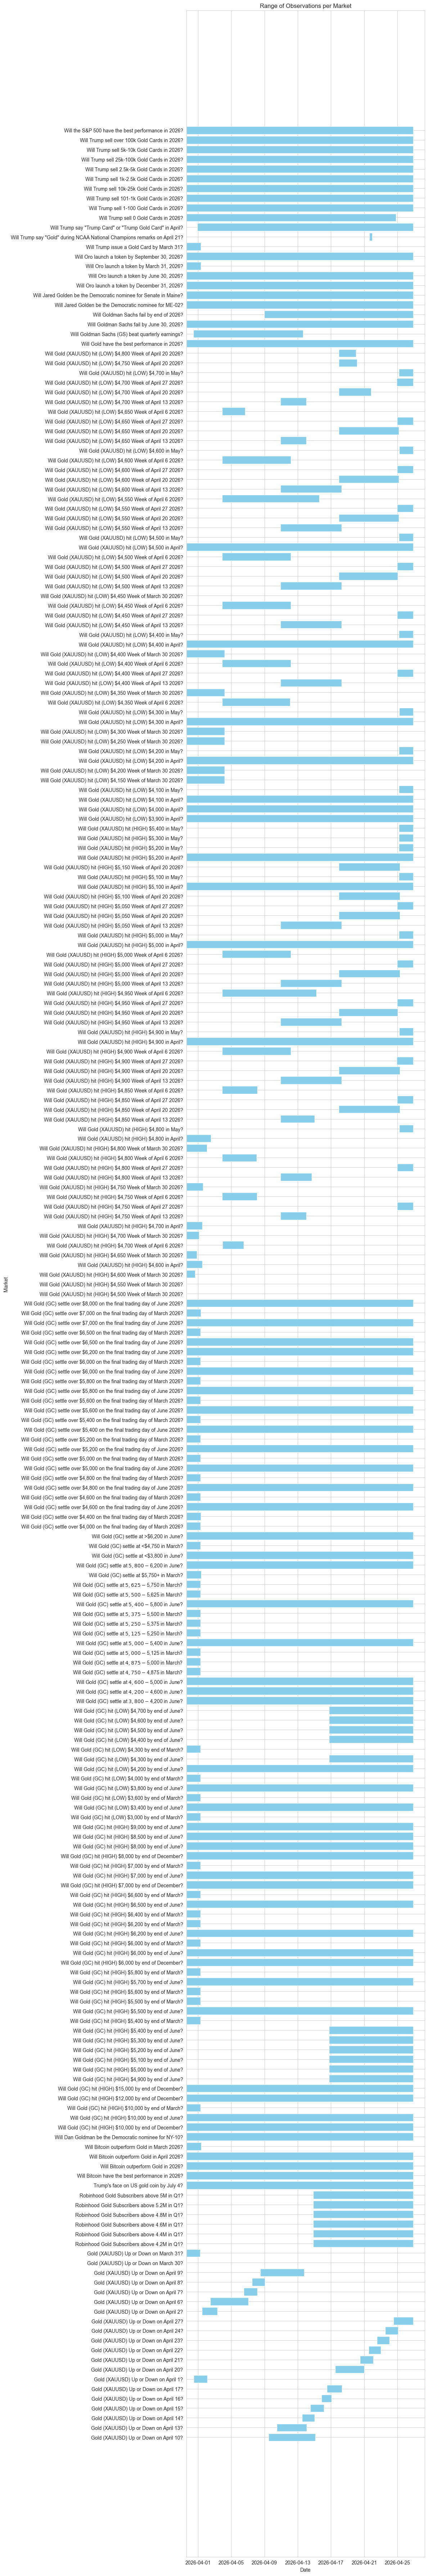

In [8]:
# Range of observations ---------------------------

# Do all markets (questions) cover the same period of time?
# Plot one horizontal bar per market from first to last non-null observation.
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(12, 0.3 * len(markets)))

for i, market in enumerate(markets):
    # Select this market from MultiIndex columns (level 1 = question/market).
    sub = df.xs(market, axis=1, level=1)
    row_has_data = sub.notna().any(axis=1)

    if not row_has_data.any():
        continue

    first_non_null = sub.index[row_has_data][0]
    last_non_null = sub.index[row_has_data][-1]
    duration_days = (last_non_null - first_non_null).total_seconds() / 86400
    plt.barh(i, duration_days, left=first_non_null, color="skyblue")

plt.yticks(range(len(markets)), markets)
plt.xlabel("Date")
plt.ylabel("Market")
plt.title("Range of Observations per Market")
plt.tight_layout()
plt.show()



In [21]:
# Keep only full-length markets ---------------------------
# We need predictors' observations to cover the entire range;
# we cannot use "spotty" markets.

# Refresh markets from the current df (the previous cell may have dropped some
# (variable, market) combinations, making the earlier `markets` list stale).
markets = df.columns.get_level_values(1).unique().tolist()

dataset_start = df.index.min()
dataset_end   = df.index.max()

# A market has "full coverage" if its first non-null observation is at the
# dataset start AND its last non-null observation is at the dataset end.
# The old `.all()` check required data at EVERY timestamp across the whole
# dataset, which fails for any market not present at the very first tick.
full_length_markets = []
for market in markets:
    sub = df.xs(market, axis=1, level=1)
    row_has_data = sub.notna().any(axis=1)
    if not row_has_data.any():
        continue
    first_obs = sub.index[row_has_data][0]
    last_obs  = sub.index[row_has_data][-1]
    if first_obs == dataset_start and last_obs == dataset_end:
        full_length_markets.append(market)

print(f"Markets with full coverage: {len(full_length_markets)} / {len(markets)}")

# Drop all (variable, market) columns for partial-coverage markets.
cols_to_drop = [col for col in df.columns if col[1] not in full_length_markets]
df_full = df.drop(columns=cols_to_drop)

print(f"Markets before filtering: {len(markets)}")
print(f"Markets after filtering:  {len(df_full.columns.get_level_values(1).unique())}")
#which market survived the filtering?
survivors = df_full.columns.get_level_values(1).unique().tolist()
print("Surviving markets:")
for m in survivors:
    print(f"  - {m}")


Markets with full coverage: 71 / 239
Markets before filtering: 239
Markets after filtering:  71
Surviving markets:
  - Trump's face on US gold coin by July 4?
  - Will Bitcoin have the best performance in 2026?
  - Will Bitcoin outperform Gold in 2026?
  - Will Bitcoin outperform Gold in April 2026?
  - Will Dan Goldman be the Democratic nominee for NY-10?
  - Will Gold (GC) hit (HIGH) $10,000 by end of December?
  - Will Gold (GC) hit (HIGH) $10,000 by end of June?
  - Will Gold (GC) hit (HIGH) $12,000 by end of December?
  - Will Gold (GC) hit (HIGH) $15,000 by end of December?
  - Will Gold (GC) hit (HIGH) $5,500 by end of June?
  - Will Gold (GC) hit (HIGH) $5,700 by end of June?
  - Will Gold (GC) hit (HIGH) $6,000 by end of December?
  - Will Gold (GC) hit (HIGH) $6,000 by end of June?
  - Will Gold (GC) hit (HIGH) $6,200 by end of June?
  - Will Gold (GC) hit (HIGH) $6,500 by end of June?
  - Will Gold (GC) hit (HIGH) $7,000 by end of December?
  - Will Gold (GC) hit (HIGH) $7,0

### Bloomberg loading for building Y and explore it

In [9]:
# %% ── CELL 3.0 : ENSURE OPENPYXL ───────────────────────────────────────────
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("openpyxl") is None:
    print("openpyxl not found. Installing via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
else:
    print("openpyxl is already installed.")


openpyxl is already installed.


In [10]:
# %% ── CELL 3 : LOAD BLOOMBERG SHEETS ────────────────────────────────────────
def load_bloomberg(xlsx_path: Path) -> dict[str, pd.DataFrame]:
    '''Load every Bloomberg sheet that has a `Date` column.
       Some sheets use `Close`, some use `Last Price` — we normalise both to `close`.'''
    xl = pd.ExcelFile(xlsx_path)
    out = {}
    for sheet in xl.sheet_names:
        df = pd.read_excel(xlsx_path, sheet_name=sheet, header=0)
        if df.empty or "Date" not in df.columns:
            continue
        df = df.rename(columns={c: c.strip() for c in df.columns})
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).set_index("Date").sort_index()
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        # normalise the price column name
        if "Close" in df.columns:
            df = df.rename(columns={"Close": "close"})
        elif "Last Price" in df.columns:
            df = df.rename(columns={"Last Price": "close"})
        else:
            numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
            if not numeric_cols:
                continue
            df = df.rename(columns={numeric_cols[-1]: "close"})
        out[sheet] = df
    return out

bb = load_bloomberg(BLOOMBERG_XLSX)
print("Bloomberg sheets loaded:", list(bb.keys()))
gold = bb[TARGET_SHEET][["close"]].rename(columns={"close": "gold_close"})
print("Gold close range:", gold.index.min(), "→", gold.index.max(), "| rows:", len(gold))


Bloomberg sheets loaded: ['GOLD USD SPOT PER OZ', 'CRUDE OIL (WTI) FUTURES PRICE', 'CRUDE OIL (BRENT) FUTURES PRICE', 'S&P 500 Index', 'USD Index', 'VIX Index', 'USGG10YR Index']
Gold close range: 2026-03-24 23:00:00 → 2026-04-17 22:55:00 | rows: 4693


### Build the target `y`
Mimiced script from Modellin Baseline

In [11]:
# %% ── CELL 3.1 : BUILD y (log-returns over RETURN_HORIZON_MIN, lagged -HORIZON_STEPS) ───
# ─── FIX (from Operation Fixing Terrible Performance, point 5) ───────────────
# We now use a CONFIGURABLE horizon. The per-bar log-return is still computed
# at the native 5-min cadence (it's what AR features need), but the TARGET is
# the log-return over HORIZON_STEPS bars ahead:
#     y_t = log(P_{t+H}) - log(P_t)
# where H = HORIZON_STEPS = RETURN_HORIZON_MIN / BAR_MINUTES.
#
# Switching RETURN_HORIZON_MIN in the config cell is the only change needed
# to move from 1h -> 4h -> next-day returns.
# Bloomberg sheets list rows newest-first; sort_index() already fixed that.
gold["logret_bar"]     = np.log(gold["gold_close"]).diff()                    # per-bar (5-min) log-return
gold["logret_horizon"] = (np.log(gold["gold_close"])
                          - np.log(gold["gold_close"]).shift(HORIZON_STEPS))  # return realised over [t-H, t]
gold["y"]              = gold["logret_horizon"].shift(-HORIZON_STEPS)         # shift forward = realised over [t, t+H]
# Backwards-compat alias (some downstream cells still reference `logret_5m`).
gold["logret_5m"]      = gold["logret_bar"]
# (gold.index = t. gold["y"].loc[t] = log(P_{t+H}) - log(P_t), i.e. the H-bar-ahead return.)
print(f"Target horizon: {RETURN_HORIZON_MIN} min  ({HORIZON_STEPS} bars of {BAR_MINUTES} min each)")
print(gold[["gold_close","logret_bar","logret_horizon","y"]].tail(6))


Target horizon: 15 min  (3 bars of 5 min each)
                     gold_close  logret_bar  logret_horizon         y
Date                                                                 
2026-04-17 22:30:00     4846.59    0.000140       -0.001070 -0.002684
2026-04-17 22:35:00     4842.36   -0.000873       -0.001302 -0.001598
2026-04-17 22:40:00     4835.34   -0.001451       -0.002184 -0.001035
2026-04-17 22:45:00     4833.60   -0.000360       -0.002684       NaN
2026-04-17 22:50:00     4834.63    0.000213       -0.001598       NaN
2026-04-17 22:55:00     4830.34   -0.000888       -0.001035       NaN


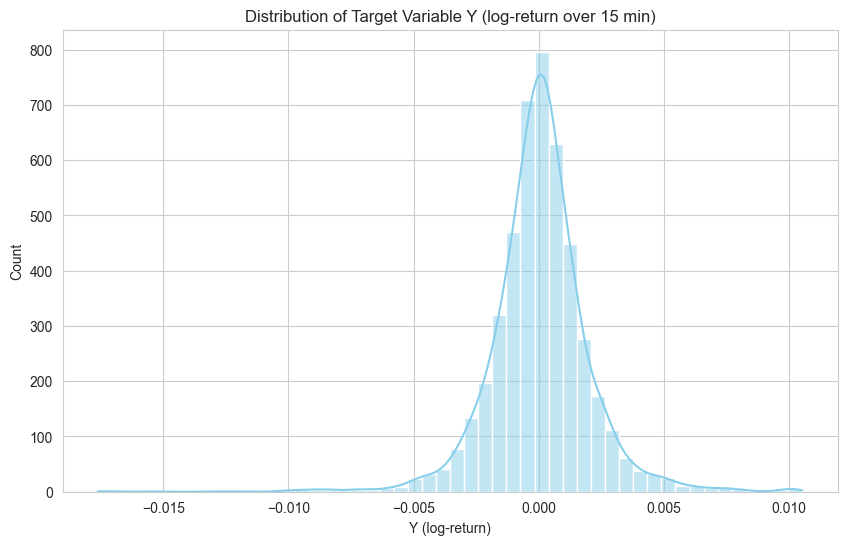

In [12]:
# Response variable distribution ---------------------------
# Using sns lineplot, let's draw the distribution of the target variable Y
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(gold["y"].dropna(), bins=50, kde=True, color="skyblue")
plt.title(f"Distribution of Target Variable Y (log-return over {RETURN_HORIZON_MIN} min)")
plt.xlabel("Y (log-return)")
plt.show()

#very nicely normally distributed with very slightly negative skew

## Feature selection (polymarket variables)


Skipped non-numeric/all-NaN/insufficient-data variables: ['acceptingOrdersTimestamp', 'clobRewards', 'createdAt', 'deployingTimestamp', 'endDate', 'endDateIso', 'eventStartTime', 'feeSchedule', 'feeType', 'gameStartTime', 'negRiskMarketID', 'negRiskRequestID', 'outcomePrices', 'outcomes', 'resolvedBy', 'startDate', 'startDateIso', 'updatedAt']
Skipped zero-range variables after coercion: ['acceptingOrders', 'active', 'approved', 'archived', 'automaticallyActive', 'closed', 'customLiveness', 'cyom', 'enableOrderBook', 'featured', 'funded', 'groupItemTitle', 'hasReviewedDates', 'holdingRewardsEnabled', 'makerBaseFee', 'manualActivation', 'negRiskOther', 'new', 'orderMinSize', 'pagerDutyNotificationEnabled', 'ready', 'restricted', 'rfqEnabled', 'showGmpOutcome', 'showGmpSeries', 'takerBaseFee', 'umaBond']


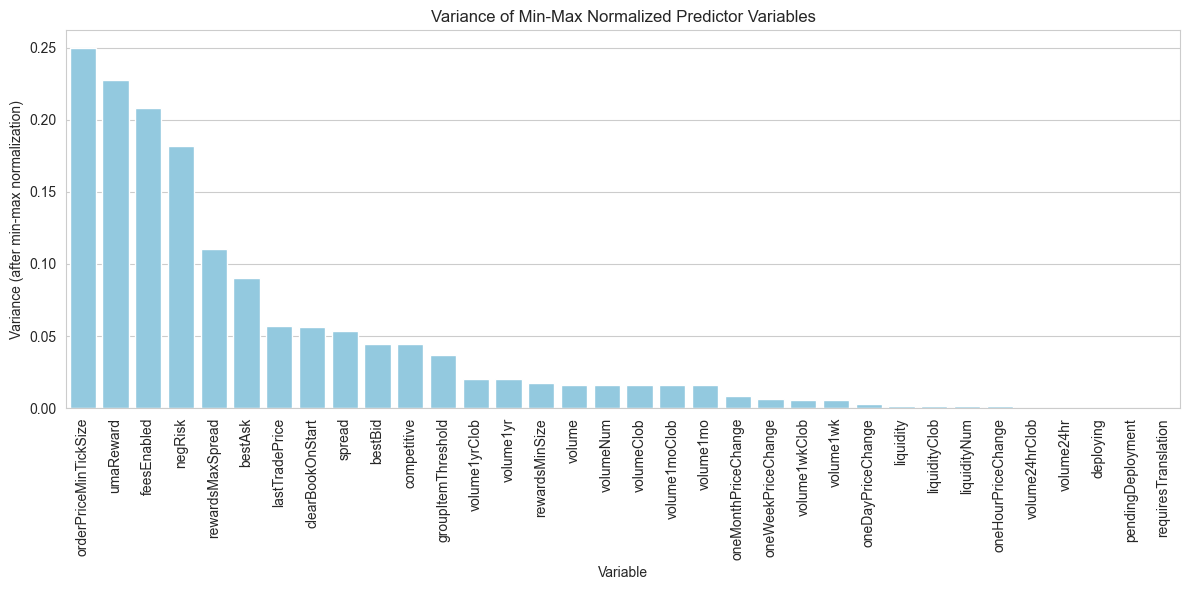

In [13]:
# Variance exploration of predictors -------------------------
# Normalize each predictor block first (min-max) so variables share a common 0..1 scale.
# Non-numeric entries are coerced to NaN; blocks with too little finite data are skipped.

predictor_vars = [col for col in df.columns.get_level_values(0).unique() if col != "gold_close"]
variances = []
skipped_non_numeric = []
skipped_zero_range = []

for var in predictor_vars:
    sub = df[var]
    numeric_sub = sub.apply(pd.to_numeric, errors="coerce")

    arr_raw = numeric_sub.to_numpy(dtype="float64")

    # Need at least 2 finite values for sample variance (ddof=1).
    if np.isfinite(arr_raw).sum() < 2:
        skipped_non_numeric.append(var)
        continue

    min_val = np.nanmin(arr_raw)
    max_val = np.nanmax(arr_raw)
    value_range = max_val - min_val
    if not np.isfinite(value_range) or value_range == 0:
        skipped_zero_range.append(var)
        continue

    arr_norm = (arr_raw - min_val) / value_range
    var_value = np.nanvar(arr_norm, ddof=1)
    if np.isnan(var_value):
        skipped_non_numeric.append(var)
        continue

    variances.append({"variable": var, "variance": var_value})

if skipped_non_numeric:
    print("Skipped non-numeric/all-NaN/insufficient-data variables:", skipped_non_numeric)
if skipped_zero_range:
    print("Skipped zero-range variables after coercion:", skipped_zero_range)

if not variances:
    raise ValueError(
        "No predictor variable had enough numeric variation after normalization."
    )

var_df = pd.DataFrame(variances).sort_values("variance", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=var_df, x="variable", y="variance", color="skyblue")
plt.xticks(rotation=90)
plt.title("Variance of Min-Max Normalized Predictor Variables")
plt.xlabel("Variable")
plt.ylabel("Variance (after min-max normalization)")
plt.tight_layout()
plt.show()

### Removing zero-variance variables


In [14]:
print(variances)
print(var_df)

[{'variable': 'bestAsk', 'variance': np.float64(0.09043533950179132)}, {'variable': 'bestBid', 'variance': np.float64(0.04467798919238245)}, {'variable': 'clearBookOnStart', 'variance': np.float64(0.056660711092132346)}, {'variable': 'competitive', 'variance': np.float64(0.04454078643169854)}, {'variable': 'deploying', 'variance': np.float64(0.0004825908892435061)}, {'variable': 'feesEnabled', 'variance': np.float64(0.20825227319074796)}, {'variable': 'groupItemThreshold', 'variance': np.float64(0.03715770729695612)}, {'variable': 'lastTradePrice', 'variance': np.float64(0.056951513339110325)}, {'variable': 'liquidity', 'variance': np.float64(0.0014081150373753658)}, {'variable': 'liquidityClob', 'variance': np.float64(0.0014081150373753658)}, {'variable': 'liquidityNum', 'variance': np.float64(0.0014081150373753658)}, {'variable': 'negRisk', 'variance': np.float64(0.18175682847983599)}, {'variable': 'oneDayPriceChange', 'variance': np.float64(0.003036194346270598)}, {'variable': 'oneH

In [15]:
# Remove near zero variance predictors ----------------
# We can assume that there is little to no predictive signal in variables with lower then 0.001 variance (after standardization)
# so let's proceed by removing ALL (variable, market) column combinations where the variable
# has cross-market variance below the threshold.
low_variance_threshold = 0.001
# var_df contains cross-market variance per variable (computed in previous cell).
low_variance_vars = set(var_df[var_df["variance"] < low_variance_threshold]["variable"].tolist())
print(f"Removing {len(low_variance_vars)} low-variance variables (variance < {low_variance_threshold}):")
print(sorted(low_variance_vars))

# df has MultiIndex columns (variable, market); drop every column whose level-0 is low-variance.
cols_to_drop = [col for col in df.columns if col[0] in low_variance_vars]
print(f"\nColumns to drop: {len(cols_to_drop)}  (= {len(low_variance_vars)} vars x markets)")
print(f"Shape before removal: {df.shape}")
df = df.drop(columns=cols_to_drop)
print(f"Shape after removal:  {df.shape}")


Removing 5 low-variance variables (variance < 0.001):
['deploying', 'pendingDeployment', 'requiresTranslation', 'volume24hr', 'volume24hrClob']

Columns to drop: 1189  (= 5 vars x markets)
Shape before removal: (7612, 17167)
Shape after removal:  (7612, 15978)


## Feature selection (markets)


# Scrapped

In [16]:
# %% -- CELL 10 : TABULAR INTEGRATION (MARKET FILTER) ----------------------------
# Build a model-ready panel by first filtering to gold-related markets.

GOLD_KEYWORDS = [
    "gold", "xauusd", "xau",
]

all_questions = df.columns.get_level_values(1).dropna().unique()
gold_questions = sorted(
    q for q in all_questions
    if isinstance(q, str) and any(kw in q.lower() for kw in GOLD_KEYWORDS)
)

if not gold_questions:
    raise ValueError(
        "No gold-related markets found. Update GOLD_KEYWORDS or inspect market names in Cell 6."
    )

print(f"Gold-related markets found : {len(gold_questions)} / {len(all_questions)}")
for i, q in enumerate(gold_questions, 1):
    print(f"  {i:>3}. {q}")

df_gold_full = df.loc[:, df.columns.get_level_values(1).isin(gold_questions)].copy()
print(f"\nShape after market filter : {df_gold_full.shape}")

Gold-related markets found : 233 / 239
    1. Gold (XAUUSD) Up or Down on April 10?
    2. Gold (XAUUSD) Up or Down on April 13?
    3. Gold (XAUUSD) Up or Down on April 14?
    4. Gold (XAUUSD) Up or Down on April 15?
    5. Gold (XAUUSD) Up or Down on April 16?
    6. Gold (XAUUSD) Up or Down on April 17?
    7. Gold (XAUUSD) Up or Down on April 1?
    8. Gold (XAUUSD) Up or Down on April 20?
    9. Gold (XAUUSD) Up or Down on April 21?
   10. Gold (XAUUSD) Up or Down on April 22?
   11. Gold (XAUUSD) Up or Down on April 23?
   12. Gold (XAUUSD) Up or Down on April 24?
   13. Gold (XAUUSD) Up or Down on April 27?
   14. Gold (XAUUSD) Up or Down on April 2?
   15. Gold (XAUUSD) Up or Down on April 6?
   16. Gold (XAUUSD) Up or Down on April 7?
   17. Gold (XAUUSD) Up or Down on April 8?
   18. Gold (XAUUSD) Up or Down on April 9?
   19. Gold (XAUUSD) Up or Down on March 30?
   20. Gold (XAUUSD) Up or Down on March 31?
   21. Robinhood Gold Subscribers above 4.2M in Q1?
   22. Robinhoo

In [17]:
# %% -- CELL 11 : TABULAR INTEGRATION (NUMERIC FILTER, FLATTEN, SAVE) ------------
# Keep only numeric, time-varying variables and flatten columns for tabular models.

import re
from hashlib import md5

NUMERIC_VARS = [
    "bestAsk",
    "bestBid",
    "lastTradePrice",
    "spread",
    "liquidityClob",
    "volume",
    "volume24hr",
    "volume1wk",
    "volume1mo",
    "oneHourPriceChange",
    "oneDayPriceChange",
    "oneWeekPriceChange",
    "oneMonthPriceChange",
]

available_vars = df_gold_full.columns.get_level_values(0).unique().tolist()
vars_to_keep = [v for v in NUMERIC_VARS if v in available_vars]
vars_dropped = [v for v in NUMERIC_VARS if v not in available_vars]
if vars_dropped:
    print(f"Variables not found in data (skipped): {vars_dropped}")

if not vars_to_keep:
    raise ValueError(
        "None of the configured NUMERIC_VARS are present after market filtering. "
        "Inspect df_gold_full.columns.get_level_values(0).unique()."
    )

df_gold_mi = df_gold_full.loc[:, df_gold_full.columns.get_level_values(0).isin(vars_to_keep)]

def _slugify(text: str, maxlen: int = 55) -> str:
    text = text.lower()[:maxlen]
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def _flat_col_name(var: str, market: str) -> str:
    # Add a short stable hash to prevent collisions between similar long question texts.
    suffix = md5(market.encode("utf-8")).hexdigest()[:6]
    return f"{var}__{_slugify(market)}_{suffix}"

df_gold = df_gold_mi.copy()
df_gold.columns = [_flat_col_name(var, mkt) for var, mkt in df_gold_mi.columns]
df_gold.index.name = SCRAPED_AT_COL

print(f"Shape after variable filter + flatten : {df_gold.shape}")
print(
    f"  -> {len(vars_to_keep)} variables x {len(gold_questions)} markets "
    f"= {len(vars_to_keep) * len(gold_questions)} columns (max; less if some combos missing)"
)
print(f"  -> {len(df_gold)} timestamp rows")

print("\nSample column names (first 5):")
for c in df_gold.columns[:5]:
    print(f"  {c}")

coverage = df_gold.notna().mean().sort_values(ascending=False)
print("\nCoverage summary (% non-null per column):")
print(f"  Median fill : {coverage.median() * 100:.1f}%")
print(f"  < 10% fill  : {(coverage < 0.10).sum()} columns")
print(f"  > 80% fill  : {(coverage > 0.80).sum()} columns")

gold_csv_name = f"gold_panel_{file_date}.csv"
gold_csv_path = Path(LOCAL_DATA_DIR) / gold_csv_name
df_gold.to_csv(gold_csv_path)
print(f"\nGold panel saved -> {gold_csv_path}")
print(f"File size : {gold_csv_path.stat().st_size / 1024:.1f} KB")

Variables not found in data (skipped): ['volume24hr']
Shape after variable filter + flatten : (7612, 2470)
  -> 12 variables x 233 markets = 2796 columns (max; less if some combos missing)
  -> 7612 timestamp rows

Sample column names (first 5):
  bestAsk__gold_xauusd_up_or_down_on_april_10_4ba50c
  bestAsk__gold_xauusd_up_or_down_on_april_13_4d2a29
  bestAsk__gold_xauusd_up_or_down_on_april_14_62ec42
  bestAsk__gold_xauusd_up_or_down_on_april_15_098dc9
  bestAsk__gold_xauusd_up_or_down_on_april_16_d0076d

Coverage summary (% non-null per column):
  Median fill : 15.6%
  < 10% fill  : 1068 columns
  > 80% fill  : 639 columns

Gold panel saved -> Data\gold_panel_2026-04-26.csv
File size : 67970.5 KB
